# Tutorial Round Data Analysis

This notebook contains exploratory data analysis for the IMC Prosperity 4 tutorial round.

The products analysed for this round were `EMERALDS` and `TOMATOES`.

The goal of the notebook is to understand the basic market behaviour of these products and identify simple features that could support an initial trading strategy. In particular, we inspect order-book features such as the bid-ask spread, the mid price, price trends, and short-horizon price movements.

In general the data consists of the order book snapshots for two trading days, which consists of three levels of bid and ask prices and volumes, as well associated profit and loss.

## 1. Data Loading and inspection

The tuturial round CSV folder need to be places in the same folder as the notebook.

Data files:
```text
prices_round_0_day_-1.csv
prices_round_0_day_-2.csv
trades_round_0_day_-1.csv
trades_round_0_day_-2.csv
```

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

In [3]:
DATA_DIR = Path("data")

In [5]:
df_prices1 = pd.read_csv(DATA_DIR / "prices_round_0_day_-1.csv", sep=";")
df_prices2 = pd.read_csv(DATA_DIR / "prices_round_0_day_-2.csv", sep=";")
df_trades1 = pd.read_csv(DATA_DIR / "trades_round_0_day_-1.csv", sep=";")
df_trades2 = pd.read_csv(DATA_DIR / "trades_round_0_day_-2.csv", sep=";")

print(df_prices1.columns)
print(df_trades1.columns)

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')
Index(['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price',
       'quantity'],
      dtype='object')


In [7]:
print(df_prices1.shape)
df_prices1.head()

(20000, 17)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


In [8]:
print(df_trades1.shape)
df_trades1.head()

(631, 7)


,timestamp,buyer,seller,symbol,currency,price,quantity
0,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2
2,5000,NaN,NaN,EMERALDS,XIRECS,9992.0,7
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5


## 2. Data Splitting and Feature Extraction

In this section, we split the price data by product and trading day. We also compute basic order-book features such as the bid-ask spread and, where needed, a clean mid price from the best bid and ask.

In [9]:
df_tomatoes1 = df_prices1[df_prices1["product"] == "TOMATOES"].copy()
df_emeralds1 = df_prices1[df_prices1["product"] == "EMERALDS"].copy()
df_tomatoes2 = df_prices2[df_prices2["product"] == "TOMATOES"].copy()
df_emeralds2 = df_prices2[df_prices2["product"] == "EMERALDS"].copy()

### 2.1 Mid-price
We first plot the mid-prices of the both thr products to understand how it is changing, this will help us come with a model for a fair-value around which we will quite our prices.

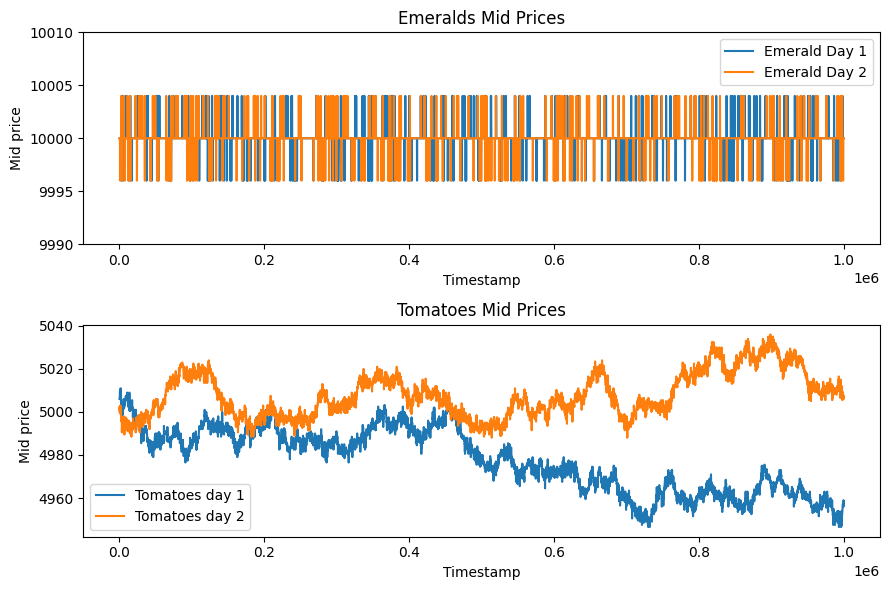

In [27]:
df_emeralds1 = df_emeralds1.sort_values("timestamp")
df_emeralds2 = df_emeralds2.sort_values("timestamp")
df_tomatoes1 = df_tomatoes1.sort_values("timestamp")
df_tomatoes2 = df_tomatoes2.sort_values("timestamp")

fig, (ax1, ax2) = plt.subplots(2,1, figsize = (9,6))
ax1.plot(df_emeralds1["timestamp"],df_emeralds1["mid_price"], label="Emerald Day 1")
ax1.plot(df_emeralds2["timestamp"],df_emeralds2["mid_price"], label="Emerald Day 2")
ax2.plot(df_tomatoes1["timestamp"], df_tomatoes1["mid_price"],label ="Tomatoes day 1")
ax2.plot(df_tomatoes2["timestamp"], df_tomatoes2["mid_price"],label ="Tomatoes day 2")
ax1.set_ylim(9990, 10010)
ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Mid price")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("Mid price")
ax1.set_title("Emeralds Mid Prices")
ax2.set_title("Tomatoes Mid Prices")
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()

### 2.2 Bid-Ask Spread

We study the histogram of the spread to find out the most frequent spreads during a trading day for a specific product.

In [29]:

df_tomatoes1["spread"] = df_tomatoes1["ask_price_1"] - df_tomatoes1["bid_price_1"]
df_tomatoes2["spread"] = df_tomatoes2["ask_price_1"] - df_tomatoes2["bid_price_1"]
df_emeralds1["spread"] = df_emeralds1["ask_price_1"] - df_emeralds1["bid_price_1"]
df_emeralds2["spread"] = df_emeralds2["ask_price_1"] - df_emeralds2["bid_price_1"]

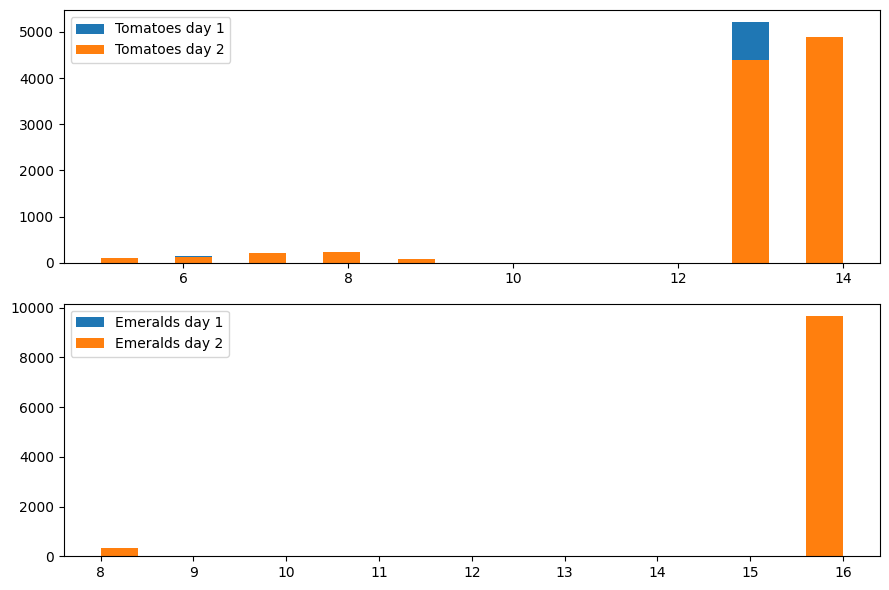

In [34]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (9,6))
ax1.hist(df_tomatoes1["spread"].values, bins = 20, label = "Tomatoes day 1")
ax1.hist(df_tomatoes2["spread"].values, bins = 20, label = "Tomatoes day 2")
ax1.legend()
ax2.hist(df_emeralds1["spread"].values, bins = 20, label = "Emeralds day 1")
ax2.hist(df_emeralds2["spread"].values, bins = 20, label = "Emeralds day 2")
ax2.legend()
plt.tight_layout()
plt.show()


### 2.3 Distribution of Bid and Ask Prices

Besides the bid-ask spread, the distribution of bid and ask prices gives additional information about where other market participants tend to quote. For a stable product, we expect the best bid and ask prices to be concentrated in a narrow region. For a more variable product, the distributions should be wider or shift noticeably across days.

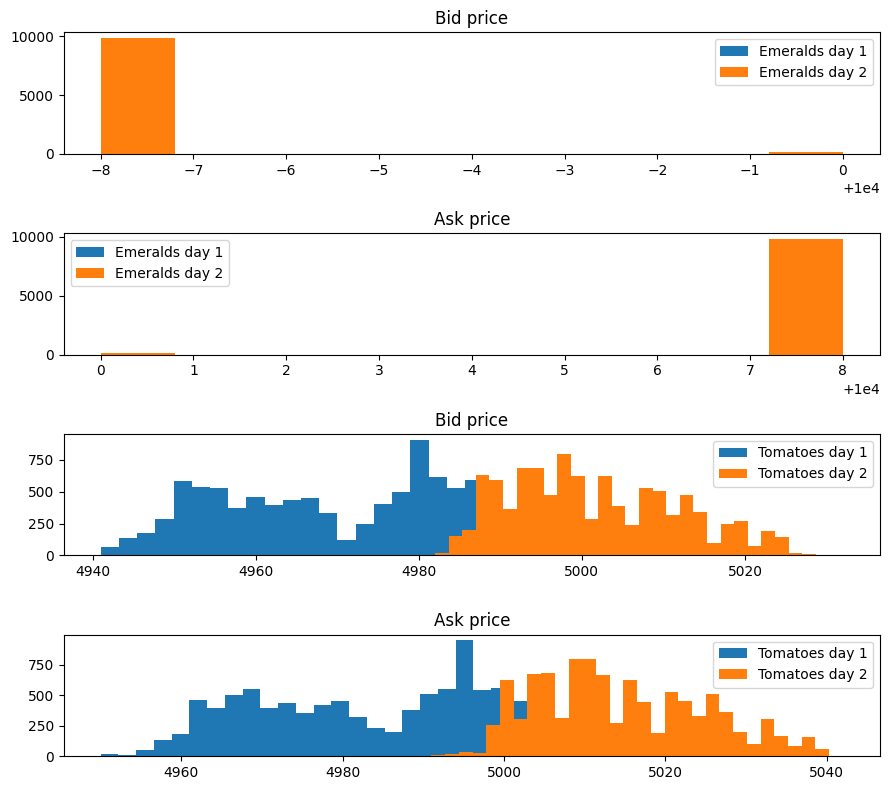

In [37]:
fig, ax = plt.subplots(4,1, figsize = (9,8))
ax[0].hist(df_emeralds1["bid_price_1"].values, label="Emeralds day 1")
ax[0].hist(df_emeralds2["bid_price_1"].values, label="Emeralds day 2")
ax[0].legend()
ax[0].set_title("Bid price")
ax[1].hist(df_emeralds1["ask_price_1"].values, label="Emeralds day 1")
ax[1].hist(df_emeralds2["ask_price_1"].values, label="Emeralds day 2")
ax[1].legend()
ax[1].set_title("Ask price")
ax[2].hist(df_tomatoes1["bid_price_1"].values, bins = 30, label = "Tomatoes day 1")
ax[2].hist(df_tomatoes2["bid_price_1"].values, bins = 30, label = "Tomatoes day 2")
ax[2].legend()
ax[2].set_title("Bid price")
ax[3].hist(df_tomatoes1["ask_price_1"].values, bins = 30, label = "Tomatoes day 1")
ax[3].hist(df_tomatoes2["ask_price_1"].values, bins = 30, label = "Tomatoes day 2")
ax[3].set_title("Ask price")
ax[3].legend()
plt.tight_layout()
plt.show()

### Initial Observations

The mid price and bid-ask spread for `EMERALDS` appear to be relatively stable across both tutorial days. This suggests that `EMERALDS` behaves like a fixed-fair-value product, at least in the tutorial data.

For `TOMATOES`, the spread is more variable, although the spread histogram suggests that it is often concentrated around 13–14. The mid-price distributions also differ across the two days, so a single fixed fair value seems less appropriate for this product.

However, the short-horizon price movements suggest that `TOMATOES` may exhibit mean-reverting behaviour. We test this more directly in the next section by comparing recent mid-price changes with subsequent mid-price changes.

### 2.4 Short-Horizon Mean-Reversion Analysis for `TOMATOES`

To test for mean reversion, we compare recent mid-price changes with subsequent mid-price changes. If `TOMATOES` is mean-reverting, then positive recent moves should be followed by negative future moves, and negative recent moves should be followed by positive future moves.

Hence, we compare

$
\qquad \text{past change} = m_t - m_{t-h}
$

with

$
\qquad \text{future change} = m_{t+h} - m_t
$

where $m_t$ is the mid price at time $t$, and $h$ is a short time horizon.

In [58]:
def analyse_reversion_for_h(h: int, df_tomatoes1: pd.DataFrame, 
                            df_tomatoes2: pd.DataFrame)-> float:
    # Copy to new dataframes
    new_df_tomatoes1 = df_tomatoes1.sort_values("timestamp").copy()
    new_df_tomatoes2 = df_tomatoes2.sort_values("timestamp").copy()
    
    # Determine past and furture change
    new_df_tomatoes1["past_change"] = new_df_tomatoes1["mid_price"]  - new_df_tomatoes1["mid_price"].shift(h)
    new_df_tomatoes1["future_change"] = new_df_tomatoes1["mid_price"].shift(-h)  - new_df_tomatoes1["mid_price"]
    new_df_tomatoes2["past_change"] = new_df_tomatoes2["mid_price"]  - new_df_tomatoes2["mid_price"].shift(h)
    new_df_tomatoes2["future_change"] = new_df_tomatoes2["mid_price"].shift(-h)  - new_df_tomatoes2["mid_price"]

    # Drop any NANs
    new_df_tomatoes1 = new_df_tomatoes1.dropna(subset = ["past_change", "future_change"])
    new_df_tomatoes2 = new_df_tomatoes2.dropna(subset = ["past_change", "future_change"])   

    # Concatenate in a new data frame
    tomatoes_reversion = pd.concat([new_df_tomatoes1[["past_change", "future_change"]], 
                                    new_df_tomatoes2[["past_change", "future_change"]],],
                                    ignore_index=True)
    tomatoes_reversion = tomatoes_reversion.dropna()

    # Compute correlation 
    corr = tomatoes_reversion["past_change"].corr(tomatoes_reversion["future_change"])
    return corr
    

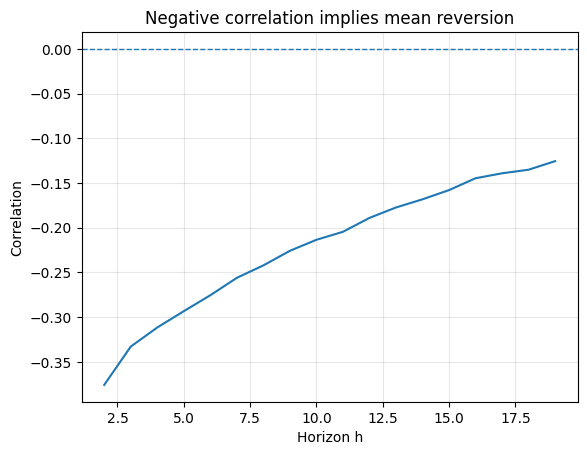

In [74]:
h_values = np.arange(2,20)
results = []

for h in h_values:
    results.append(analyse_reversion_for_h(h=h, df_tomatoes1 = df_tomatoes1, df_tomatoes2 = df_tomatoes2))

results = np.array(results)
plt.plot(h_values,results)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Horizon h")
plt.ylabel("Correlation")
plt.title("Negative correlation implies mean reversion")
plt.grid(True, alpha=0.3)

plt.show()

### Conclusion
The correlation between past and future mid-price changes is negative for all tested horizons. This provides evidence of short-horizon mean-reverting behaviour in `TOMATOES` in the tutorial data. The strongest reversal signal appears at the shortest tested horizons, and the effect weakens as the horizon increases.

This is check based only on tutorial-round data. A trading strategy would still need to account for the bid-ask spread, position limits, execution risk, and whether the effect survives in later data.

## 3. Summary of Findings

The tutorial data suggests that `EMERALDS` behaves like a relatively stable product with a near-fixed mid price and tight spread behaviour. This makes it suitable for a simple fair-value strategy around a stable reference price.

`TOMATOES` shows more variable price behaviour across the two tutorial days. Its spread is wider and more variable, and the mid-price distribution shifts across days, suggesting that a static fair value might be appropriate.

The short-horizon analysis for `TOMATOES` shows negative correlation between recent and future mid-price changes across several horizons. This provides evidence of short-horizon mean-reverting behaviour, with the strongest reversal effect appearing at the shortest tested horizons.

These observations motivated simple tutorial-round strategies based on fixed fair-value trading for `EMERALDS` and short-horizon mean-reversion ideas for `TOMATOES`.